In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [3]:
#importo il dataset
df = pd.read_csv('student_burnout_dropout_dataset_2.csv')
df_clean = df.dropna()
df_clean = df_clean.drop(columns=['Student_ID'])
print(df_clean['Dropout_Risk'].value_counts(normalize=True) * 100)  #stampo la distribuzione della colonna target Dropout_Risk
print(df_clean['Burnout_Level'].value_counts(normalize=True) * 100)  #stampo la distribuzione della colonna target Burnout_Level

Dropout_Risk
Yes    54.444444
No     45.555556
Name: proportion, dtype: float64
Burnout_Level
Low       38.888889
Medium    35.555556
High      25.555556
Name: proportion, dtype: float64


In [4]:
cat_cols = df_clean.select_dtypes(include='str').columns    #seleziono le colonne categoriche

#converto le colonne categoriche in numeriche
for column in cat_cols:
    le = LabelEncoder()
    df_clean[column] = le.fit_transform(df_clean[column])
    

In [5]:
X = df_clean.drop(columns=['Dropout_Risk', 'Burnout_Level'])  #rimuovo le colonne target
y_1 = df_clean['Dropout_Risk']  #colonna target per il dropout
y_2 = df_clean['Burnout_Level']  #colonna target per il burnout

#standardizzo le feature
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
#suddivido il dataset in training e test set per il dropout
X_train_dropout, X_test_dropout, y_train_dropout, y_test_dropout = train_test_split(X, y_1, test_size=0.2, random_state=42)

#suddivido il dataset in training e test set per il burnout
X_train_burnout, X_test_burnout, y_train_burnout, y_test_burnout = train_test_split(X, y_2, test_size=0.2, random_state=42)


In [ ]:
#Applicazione dei modelli per il target Dropout_Risk

#Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_dropout, y_train_dropout)  #addestramento del modello per il dropout
y_pred_dropout_clf = clf.predict(X_test_dropout)  #predizione sul test set

#Support Vector Machine Classifier
svc = CalibratedClassifierCV(SVC(), ensemble=False)  #inizializzazione del modello SVC con kernel lineare
svc.fit(X_train_dropout, y_train_dropout)  #addestramento del modello per il dropout
y_pred_dropout_svc = svc.predict(X_test_dropout)  #predizione sul test set

#Logistic Regression Classifier
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_dropout, y_train_dropout)  #addestramento del modello per il dropout
y_pred_dropout_logreg = logreg.predict(X_test_dropout)  #predizione sul test set


In [ ]:
#Applicazione del Random Forest Classifier per il burnout
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_burnout, y_train_burnout)  #addestramento del modello per il burnout
y_pred_burnout_rf = rf.predict(X_test_burnout)  #predizione sul test set

#Applicazione del k-nearest neighbors per il burnout
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_burnout, y_train_burnout)  #addestramento del modello per il burnout
y_pred_burnout_knn = knn.predict(X_test_burnout)  #predizione sul test set

#Applicazione del GradientBoostingClassifier
gbc = GradientBoostingClassifier(random_state=42, max_depth=3)
gbc.fit(X_train_burnout, y_train_burnout)  #addestramento del modello per il burnout
y_pred_burnout_gbc = gbc.predict(X_test_burnout)  #predizione sul test set

Valutazione del modello Decision Tree per il Dropout:


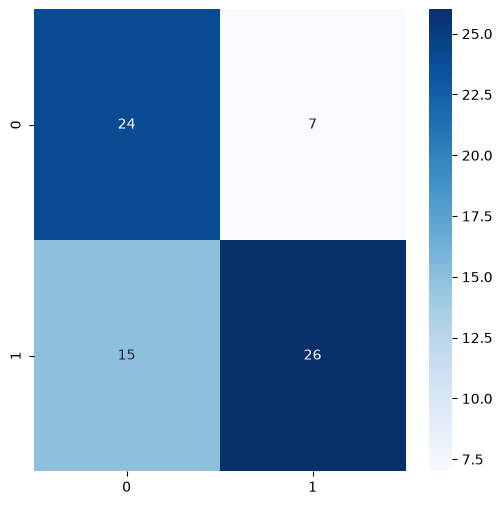

Accuracy Score for Decision Tree:
0.6944444444444444
Valutazione del modello SVC per il Dropout:


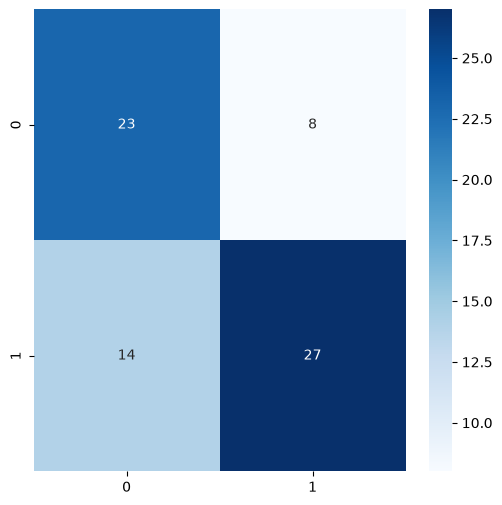

Accuracy Score for SVC:
0.6944444444444444
Valutazione del modello Logistic Regression per il Dropout:


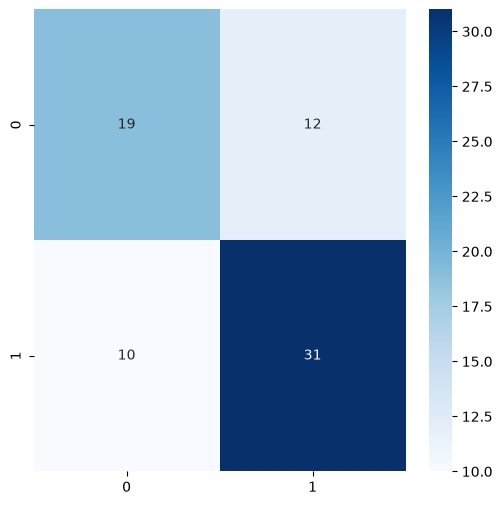

Accuracy Score for Logistic Regression:
0.6944444444444444


In [18]:
#Valutazione dei modelli per il target Dropout_Risk
print("Valutazione del modello Decision Tree per il Dropout:")
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_test_dropout, y_pred_dropout_clf), annot=True, fmt='d', cmap='Blues')
plt.show()
print("Accuracy Score for Decision Tree:")    #accuracy intorno al 70% per il dropout, considerato che la distribuzione della colonna target è equamente bilanciata, il risultato è soddisfacente
print(accuracy_score(y_test_dropout, y_pred_dropout_clf))


print("Valutazione del modello SVC per il Dropout:")
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_test_dropout, y_pred_dropout_svc), annot=True, fmt='d', cmap='Blues')
plt.show()
print("Accuracy Score for SVC:")
print(accuracy_score(y_test_dropout, y_pred_dropout_svc))

print("Valutazione del modello Logistic Regression per il Dropout:")
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_test_dropout, y_pred_dropout_logreg), annot=True, fmt='d', cmap='Blues')
plt.show()
print("Accuracy Score for Logistic Regression:")
print(accuracy_score(y_test_dropout, y_pred_dropout_logreg))

#scores_dropout = cross_val_score(clf, X, y_1, cv=5)  #cross validation per il dropout
#print("Mean Cross Validation Score for Dropout:", scores_dropout.mean())


Valutazione del modello Random Forest per il Burnout:
Accuracy Score for Random Forest:
0.4861111111111111


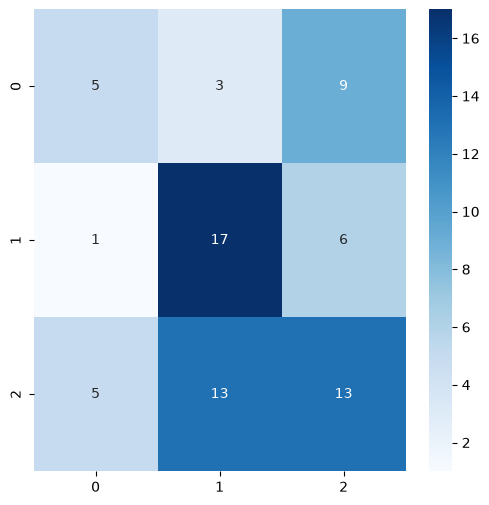

Valutazione del modello KNN per il Burnout:
Accuracy Score for KNN:
0.5972222222222222


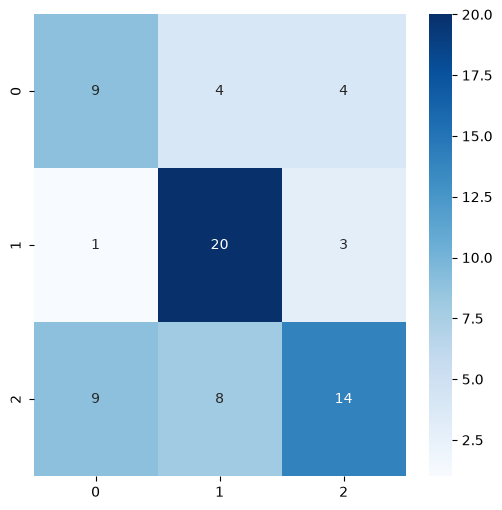

Valutazione del modello Gradient Boosting Classifier per il Burnout:
Accuracy Score for Gradient Boosting Classifier:
0.5277777777777778


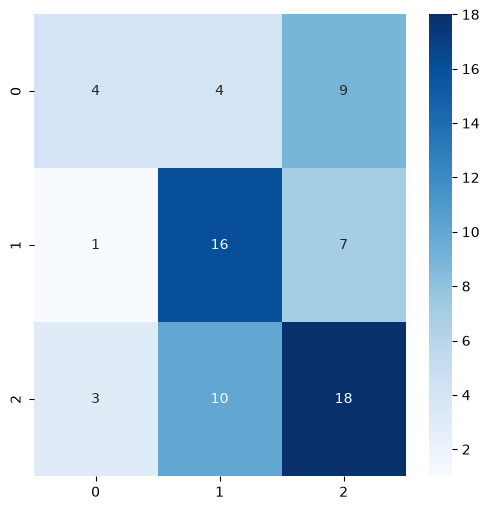

In [19]:
#Valutazione dei modelli per il burnout
print("Valutazione del modello Random Forest per il Burnout:")
print("Accuracy Score for Random Forest:")
print(accuracy_score(y_test_burnout, y_pred_burnout_rf))
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_test_burnout, y_pred_burnout_rf), annot=True, fmt='d', cmap='Blues')
plt.show()


print("Valutazione del modello KNN per il Burnout:")
print("Accuracy Score for KNN:")
print(accuracy_score(y_test_burnout, y_pred_burnout_knn))
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_test_burnout, y_pred_burnout_knn), annot=True, fmt='d', cmap='Blues')
plt.show()

print("Valutazione del modello Gradient Boosting Classifier per il Burnout:")
print("Accuracy Score for Gradient Boosting Classifier:")
print(accuracy_score(y_test_burnout, y_pred_burnout_gbc))
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_test_burnout, y_pred_burnout_gbc), annot=True, fmt='d', cmap='Blues')
plt.show()

#scores_burnout = cross_val_score(rf, X, y_2, cv=5)  #cross validation per il burnout
#print("Mean Cross Validation Score for Burnout:", scores_burnout.mean())


Ottimizzazione del modello GradientBoosting

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=42)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [2, 3, 4, 5]
}

grid_search = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # o 'f1', 'roc_auc' se classi sbilanciate
    n_jobs=-1,                # usa tutti i core disponibili
    verbose=1
)

grid_search.fit(X_train_burnout, y_train_burnout)

print("Migliori parametri:", grid_search.best_params_)
print("Miglior accuracy CV:", grid_search.best_score_)

# Il modello già allenato con i parametri migliori
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Migliori parametri: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}
Miglior accuracy CV: 0.5866303690260134


In [24]:
#Applicazione del GradientBoostingClassifier Ottimizzato
gbc_opt = GradientBoostingClassifier(random_state=42, max_depth=3, learning_rate=0.2, n_estimators=300)
gbc_opt.fit(X_train_burnout, y_train_burnout)  #addestramento del modello per il burnout
y_pred_burnout_gbc_opt = gbc_opt.predict(X_test_burnout)  #predizione sul test set

print("Accuracy Score for GradientBoostingClassifier Ottimizzato:")
print(accuracy_score(y_test_burnout, y_pred_burnout_gbc_opt))

Accuracy Score for GradientBoostingClassifier Ottimizzato:
0.5416666666666666


Ottimizzazione del modello SVC

In [22]:

svc_opt = SVC(random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}


grid_search = GridSearchCV(
    estimator=svc_opt,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # o 'f1', 'roc_auc' se classi sbilanciate
    n_jobs=-1,                # usa tutti i core disponibili
    verbose=1
)

grid_search.fit(X_train_burnout, y_train_burnout)

print("Migliori parametri:", grid_search.best_params_)
print("Miglior accuracy CV:", grid_search.best_score_)

# Il modello già allenato con i parametri migliori
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Migliori parametri: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Miglior accuracy CV: 0.6771929824561403


In [23]:
#Support Vector Machine Classifier Ottimizzato
svc_opt = CalibratedClassifierCV(SVC(kernel='linear', gamma='scale', C=100), ensemble=False)  #inizializzazione del modello SVC con kernel lineare
svc_opt.fit(X_train_dropout, y_train_dropout)  #addestramento del modello per il dropout
y_pred_dropout_svc_opt = svc_opt.predict(X_test_dropout)  #predizione sul test set

print("Accuracy Score for SVC:")
print(accuracy_score(y_test_dropout, y_pred_dropout_svc_opt))



Accuracy Score for SVC:
0.7222222222222222
